In [1]:
# ======================== CELL 1: SETUP & IMPORTS ========================
import os
# This MUST be set before torch is imported to bypass Apple's memory cap
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

# PAPER-FAITHFUL CRNN-DF + SPARSE-FBGAN
%matplotlib inline

import gc, time, pickle, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, welch
from scipy.linalg import eigh
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Device:", device)

Device: mps


In [2]:
# ======================== CONFIG (UPDATED FOR MEMORY) ========================
BUNDLE_PATH = "eeg_bundle.pkl"
FS = 250
N_CH = 22
N_T = 1000
N_CLASSES = 4
CLASSES = ["Left hand", "Right hand", "Feet", "Tongue"]
BANDS = [(1,4), (4,8), (8,12), (12,16), (16,20), (20,24), (24,28), (28,32), (32,35), (35,38)]

CSP_PER_CLASS = 4
LASSO_MIN = 8
LASSO_MAX = 64

CRNN_EPOCHS = 200
WARMUP = 30
CRNN_BATCH = 32
CRNN_LR = 1e-4
LAM_CENTER = .10
LAM_INTER = .01
CENTER_ALPHA = .5
DROPOUT = .5

NOISE_DIM = 1600
GAN_EPOCHS = 300

# REDUCED: Lowered batch size from 16 to 8 to prevent Mac OOM crashes
GAN_BATCH = 8  
GAN_LR_G = 2e-4
GAN_LR_D = 5e-5
N_FAKE_PER_CLASS = 750

RUN_DEMO = True
DEMO_SUBJECT = "1"
RUN_FULL_LOSO = False

PAPER_CRNN = {"1":65.51, "2":45.18, "3":78.62, "4":53.58, "5":55.64, "6":56.03, "7":71.28, "8":75.02, "9":70.78}
PAPER_GAN = {"1":79.60, "2":54.25, "3":83.84, "4":60.93, "5":70.54, "6":62.18, "7":79.94, "8":82.01, "9":81.36}

In [3]:
# ======================== LOAD ========================
assert os.path.exists(BUNDLE_PATH), f"{BUNDLE_PATH} not found. Please ensure the file is in the working directory."

with open(BUNDLE_PATH, "rb") as f: 
    bundle = pickle.load(f)

X_raw = np.asarray(bundle["X_raw"], np.float32)
y = np.asarray(bundle["y"], np.int64)
subjects = np.asarray(bundle["subjects"]).astype(str)
sessions = np.asarray(bundle["sessions"]).astype(str)

S0 = str(bundle.get("S0", sorted(np.unique(sessions))[0]))
S1 = str(bundle.get("S1", sorted(np.unique(sessions))[1]))

print("Data:", X_raw.shape, "classes:", np.bincount(y, minlength=4))
print("Subjects:", sorted(np.unique(subjects)), "sessions:", sorted(np.unique(sessions)))

Data: (5184, 22, 1000) classes: [1296 1296 1296 1296]
Subjects: [np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9')] sessions: [np.str_('0train'), np.str_('1test')]


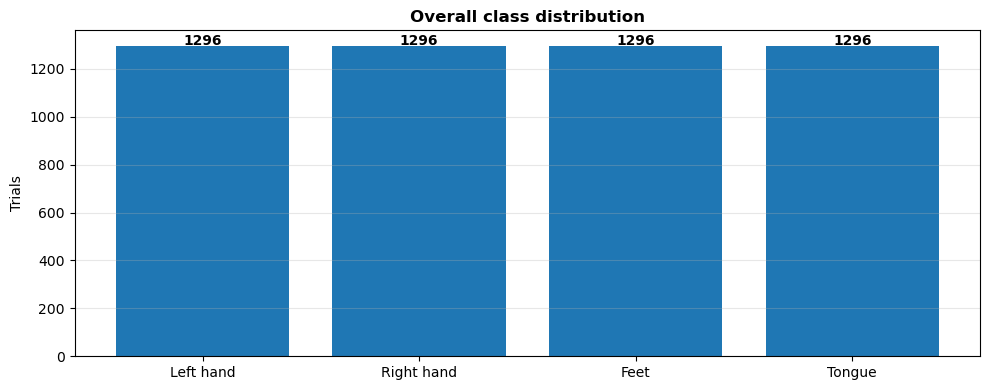

Subject Session  Trials  Left hand  Right hand  Feet  Tongue
      1  0train     288         72          72    72      72
      1   1test     288         72          72    72      72
      2  0train     288         72          72    72      72
      2   1test     288         72          72    72      72
      3  0train     288         72          72    72      72
      3   1test     288         72          72    72      72
      4  0train     288         72          72    72      72
      4   1test     288         72          72    72      72
      5  0train     288         72          72    72      72
      5   1test     288         72          72    72      72
      6  0train     288         72          72    72      72
      6   1test     288         72          72    72      72
      7  0train     288         72          72    72      72
      7   1test     288         72          72    72      72
      8  0train     288         72          72    72      72
      8   1test     288 

In [4]:
# ======================== INFO MAP ========================
plt.figure(figsize=(10,4))
counts = np.bincount(y, minlength=4)
plt.bar(CLASSES, counts)
plt.title("Overall class distribution", fontweight="bold")
plt.ylabel("Trials")
plt.grid(axis="y", alpha=.3)

for i, v in enumerate(counts): 
    plt.text(i, v+5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

rows = []
for s in sorted(np.unique(subjects), key=lambda z: int(z)):
    for sess in sorted(np.unique(sessions)):
        m = (subjects == s) & (sessions == sess)
        c = np.bincount(y[m], minlength=4)
        rows.append([s, sess, len(y[m]), *c])

print(pd.DataFrame(rows, columns=["Subject", "Session", "Trials", *CLASSES]).to_string(index=False))

In [5]:
# ======================== PREPROCESS ========================
def bandpass_np(X, lo, hi, fs=FS, order=4):
    sos = butter(order, [lo, hi], btype="bandpass", fs=fs, output="sos")
    return sosfiltfilt(sos, X, axis=-1).astype(np.float32)

def preprocess(X): 
    return bandpass_np(X, 1, 38)

def prepare_fold(test_subj):
    test_subj = str(test_subj)
    ms = subjects != test_subj
    mc = (subjects == test_subj) & (sessions == S0)
    mt = (subjects == test_subj) & (sessions == S1)
    
    Xs, Xc, Xt = preprocess(X_raw[ms]), preprocess(X_raw[mc]), preprocess(X_raw[mt])
    
    # UPDATED: Trial-wise (Instance) Normalization
    # We calculate the mean and std along axis=-1 (the time dimension) for each trial individually.
    def norm(X):
        mu = X.mean(axis=-1, keepdims=True)
        sd = X.std(axis=-1, keepdims=True) + 1e-6
        return ((X - mu) / sd).astype(np.float32)
        
    return norm(Xs), y[ms], norm(Xc), y[mc], norm(Xt), y[mt]

In [6]:
# ======================== FBCSP + LASSO ========================
def mean_cov(X):
    cs = []
    for t in X:
        C = t @ t.T
        cs.append(C / (np.trace(C) + 1e-10))
    return np.mean(cs, 0)

def fit_binary_csp(Xp, Xn, n_comp=CSP_PER_CLASS):
    Cp, Cn = mean_cov(Xp), mean_cov(Xn)
    vals, vecs = eigh(Cp, Cp + Cn + 1e-8 * np.eye(Cp.shape[0]))
    vecs = vecs[:, np.argsort(vals)[::-1]]
    a = n_comp // 2
    b = n_comp - a
    return np.concatenate([vecs[:, :a], vecs[:, -b:]], 1).astype(np.float32)

def csp_logvar(X, W):
    # FIXED: "fc" (Filters, Channels) x "ncs" (Trials, Channels, Samples) -> "nfs" (Trials, Filters, Samples)
    Z = np.einsum("fc,ncs->nfs", W.T, X)
    v = np.var(Z, -1)
    v /= v.sum(1, keepdims=True) + 1e-10
    return np.log(v + 1e-10).astype(np.float32)

def fit_fbcsp(X, yv):
    feats = []; filters = []; meta = []
    for bi, (lo, hi) in enumerate(BANDS):
        Xb = bandpass_np(X, lo, hi)
        bf = []
        for cls in range(4):
            W = fit_binary_csp(Xb[yv == cls], Xb[yv != cls])
            bf.append(csp_logvar(Xb, W))
            for wi in range(W.shape[1]):
                filters.append(W[:, wi])
                meta.append((bi, cls, wi, lo, hi))
        feats.append(np.concatenate(bf, 1))
    return np.concatenate(feats, 1), np.stack(filters, 1).astype(np.float32), meta

def fit_sparse_fbcsp(Xcal, ycal):
    Fv, W, meta = fit_fbcsp(Xcal, ycal)
    sc = StandardScaler()
    Fs = sc.fit_transform(Fv)
    la = LassoCV(cv=5, max_iter=50000, random_state=SEED, n_jobs=-1).fit(Fs, ycal.astype(float))
    
    co = np.abs(la.coef_)
    idx = np.where(co > 1e-10)[0]
    
    if len(idx) < LASSO_MIN: 
        idx = np.argsort(co)[::-1][:LASSO_MIN]
    if len(idx) > LASSO_MAX: 
        idx = idx[np.argsort(co[idx])[::-1][:LASSO_MAX]]
        
    idx = np.sort(idx)
    return {"W_sparse": W[:, idx], "meta_sparse": [meta[i] for i in idx], "idx": idx, "coef": co}

In [7]:
# ======================== CRNN-DF ========================
class CRNN_DF(nn.Module):
    def __init__(self, n_filters=32, hidden=64):
        super().__init__()
        self.feature_dim = hidden
        self.conv = nn.Conv2d(1, n_filters, (N_CH, 45), bias=False)
        self.bn = nn.BatchNorm2d(n_filters)
        self.act = nn.ReLU()
        self.drop1 = nn.Dropout(DROPOUT)
        self.pool = nn.MaxPool2d((1, 75), stride=(1, 10))
        self.lstm = nn.LSTM(n_filters, hidden, num_layers=2, batch_first=True, dropout=DROPOUT)
        self.drop2 = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(hidden, 4)
        
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.drop1(self.act(self.bn(self.conv(x))))
        x = self.pool(x).squeeze(2).permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        feat = self.drop2(h[-1])
        return self.fc(feat), feat

class DFLoss(nn.Module):
    def __init__(self, feat_dim=64, margin=5.0):
        super().__init__()
        self.margin = margin
        self.register_buffer("centers", torch.zeros(4, feat_dim))
        
    @torch.no_grad()
    def initialize(self, model, X, yv, bs=128):
        model.eval()
        FF = []
        Xt = torch.from_numpy(X).float()
        for i in range(0, len(Xt), bs):
            _, f = model(Xt[i:i+bs].to(device))
            FF.append(f.cpu())
        FF = torch.cat(FF)
        for c in range(4):
            self.centers[c] = FF[torch.from_numpy(yv) == c].mean(0).to(device)
        model.train()
        
    def intra(self, f, l):
        return ((f - self.centers[l].detach())**2).sum(1).mean()
        
    def inter(self):
        d = torch.cdist(self.centers, self.centers)
        mask = ~torch.eye(4, dtype=torch.bool, device=d.device)
        return F.relu(self.margin - d[mask]).pow(2).mean()
        
    @torch.no_grad()
    def update(self, f, l):
        for c in range(4):
            m = l == c
            if m.any():
                bc = f[m].detach().mean(0)
                self.centers[c].mul_(1 - CENTER_ALPHA).add_(CENTER_ALPHA * bc)

def loader(X, yv, bs=32, shuffle=True):
    return DataLoader(TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(yv).long()),
                      batch_size=bs, shuffle=shuffle, drop_last=False)

def train_crnn(X, yv, epochs=CRNN_EPOCHS, verbose=True):
    m = CRNN_DF().to(device)
    df = DFLoss(m.feature_dim).to(device)
    opt = optim.Adam(m.parameters(), lr=CRNN_LR)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    ce = nn.CrossEntropyLoss()
    dl = loader(X, yv, CRNN_BATCH, True)
    
    H = {"loss": [], "ce": [], "center": [], "inter": [], "acc": []}
    
    for ep in range(1, epochs + 1):
        if ep == WARMUP + 1: 
            df.initialize(m, X, yv)
            
        sums = np.zeros(4); cor = n = 0
        m.train()
        
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, feat = m(xb)
            lc = ce(logits, yb)
            
            if ep > WARMUP:
                lcen = df.intra(feat, yb)
                lint = df.inter()
                loss = lc + LAM_CENTER * lcen + LAM_INTER * lint
            else:
                lcen = torch.tensor(0., device=device)
                lint = torch.tensor(0., device=device)
                loss = lc
                
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            
            if ep > WARMUP: 
                df.update(feat, yb)
                
            sums += [loss.item(), lc.item(), lcen.item(), lint.item()]
            cor += (logits.argmax(1) == yb).sum().item()
            n += len(yb)
            
        sch.step()
        for k, v in zip(["loss", "ce", "center", "inter"], sums / len(dl)): 
            H[k].append(v)
            
        H["acc"].append(100 * cor / n)
        if verbose and (ep == 1 or ep % 25 == 0):
            print(f"CRNN ep {ep:3d}/{epochs} loss={H['loss'][-1]:.4f} train={H['acc'][-1]:.1f}%")
            
    return m, H

@torch.no_grad()
def predict(model, X, bs=128):
    model.eval()
    pp = []; ff = []
    Xt = torch.from_numpy(X).float()
    for i in range(0, len(Xt), bs):
        l, f = model(Xt[i:i+bs].to(device))
        pp.append(torch.softmax(l, 1).cpu().numpy())
        ff.append(f.cpu().numpy())
    return np.vstack(pp), np.vstack(ff)

In [8]:
# ======================== DIFFERENTIABLE SPARSE FB PATH ========================
class SparseFBTransform(nn.Module):
    def __init__(self, pack):
        super().__init__()
        W = pack["W_sparse"]
        meta = pack["meta_sparse"]
        self.register_buffer("W", torch.tensor(W, dtype=torch.float32))
        freqs = torch.fft.rfftfreq(N_T, d=1/FS)
        masks = []
        for m in meta:
            lo, hi = BANDS[m[0]]
            masks.append(((freqs >= lo) & (freqs < hi)).float())
        self.register_buffer("masks", torch.stack(masks))
        
    def forward(self, x):
        Xf = torch.fft.rfft(x, dim=-1)
        Xfb = Xf.unsqueeze(1) * self.masks[None, :, None, :]
        xb = torch.fft.irfft(Xfb, n=N_T, dim=-1)
        return torch.einsum("ck,bkct->bkt", self.W, xb)

# ======================== FBGAN ========================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Start natively at N_CH (22) and a low temporal resolution (125)
        # 125 * 2 * 2 * 2 = 1000 (perfect temporal scaling)
        self.fc = nn.Linear(NOISE_DIM, 128 * N_CH * 125)
        
        self.net = nn.Sequential(
            # Input: (bs, 128, 22, 125)
            # Upsample time by 2x: (bs, 64, 22, 250)
            nn.ConvTranspose2d(128, 64, kernel_size=(1, 4), stride=(1, 2), padding=(0, 1)),
            nn.InstanceNorm2d(64, affine=True), 
            nn.LeakyReLU(0.2, True),
            
            # Upsample time by 2x: (bs, 32, 22, 500)
            nn.ConvTranspose2d(64, 32, kernel_size=(1, 4), stride=(1, 2), padding=(0, 1)),
            nn.InstanceNorm2d(32, affine=True), 
            nn.LeakyReLU(0.2, True),
            
            # Upsample time by 2x: (bs, 16, 22, 1000)
            nn.ConvTranspose2d(32, 16, kernel_size=(1, 4), stride=(1, 2), padding=(0, 1)),
            nn.InstanceNorm2d(16, affine=True), 
            nn.LeakyReLU(0.2, True),
            
            # Final projection to 1 channel (bs, 1, 22, 1000)
            # We use a 5x5 Conv2d to smooth out checkerboard artifacts across both time and channels
            nn.Conv2d(16, 1, kernel_size=(5, 5), padding=(2, 2))
        )
        
    def forward(self, z):
        # Shape z into our foundational spatial-temporal block
        x = self.fc(z).view(z.size(0), 128, N_CH, 125)
        x = self.net(x)
        return x.squeeze(1)

class Dphi(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(1, 32, (3, 15), (1, 3), (1, 6))), nn.LeakyReLU(.2, True),
            nn.Dropout2d(0.3),
            nn.utils.spectral_norm(nn.Conv2d(32, 64, (3, 15), (1, 3), (1, 6))), nn.LeakyReLU(.2, True),
            nn.MaxPool2d((2, 2)),
            nn.Dropout2d(0.3),
            nn.utils.spectral_norm(nn.Conv2d(64, 128, (3, 5), (1, 2), (1, 2))), nn.LeakyReLU(.2, True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.utils.spectral_norm(nn.Linear(128, 1))
        
    def forward(self, x): 
        return self.fc(self.net(x.unsqueeze(1)).flatten(1))

class Dpsi(nn.Module):
    def __init__(self, k):
        super().__init__()
        self.net = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv1d(k, 64, 15, 3, 7)), nn.LeakyReLU(.2, True),
            nn.Dropout1d(0.3),
            nn.utils.spectral_norm(nn.Conv1d(64, 128, 15, 3, 7)), nn.LeakyReLU(.2, True),
            nn.MaxPool1d(4), 
            nn.Dropout1d(0.3),
            nn.utils.spectral_norm(nn.Conv1d(128, 128, 5, 2, 2)), nn.LeakyReLU(.2, True),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.utils.spectral_norm(nn.Linear(128, 1))
        
    def forward(self, z): 
        return self.fc(self.net(z).squeeze(-1))

In [9]:
# ======================== CELL 9: GAN TRAINING LOOP ========================
def train_gan_class(Xc, pack, epochs=GAN_EPOCHS):
    fb = SparseFBTransform(pack).to(device)
    G = Generator().to(device)
    dp = Dphi().to(device)
    ds = Dpsi(pack["W_sparse"].shape[1]).to(device)
    
    og = optim.Adam(G.parameters(), lr=GAN_LR_G, betas=(.5, .999))
    od = optim.Adam(list(dp.parameters()) + list(ds.parameters()), lr=GAN_LR_D, betas=(.5, .999))
    criterion = nn.MSELoss()
    dl = DataLoader(TensorDataset(torch.from_numpy(Xc).float()), batch_size=min(GAN_BATCH, len(Xc)), shuffle=True)
    
    H = {"G": [], "D": [], "Dphi": [], "Dpsi": []}
    
    for ep in range(1, epochs + 1):
        sg = sd = sp = ss = 0.; nb = 0
        for (real,) in dl:
            real = real.to(device)
            bs = len(real)
            one = torch.ones(bs, 1, device=device)
            zero = torch.zeros(bs, 1, device=device)
            
            # --- Train Discriminator (1 Step) ---
            od.zero_grad()
            with torch.no_grad(): 
                fake = G(torch.randn(bs, NOISE_DIM, device=device))
                
            lp = criterion(dp(real), one) + criterion(dp(fake), zero)
            ls = criterion(ds(fb(real)), one) + criterion(ds(fb(fake)), zero)
            ld = 0.5 * (lp + ls)
            ld.backward()
            od.step()
            
            # --- Train Generator (2 Steps) ---
            for _ in range(2):
                og.zero_grad()
                fake = G(torch.randn(bs, NOISE_DIM, device=device))
                
                lg_p = criterion(dp(fake), one)
                lg_s = criterion(ds(fb(fake)), one)
                lg = 0.5 * (lg_p + lg_s)
                lg.backward()
                og.step()
            
            sg += lg.item(); sd += ld.item(); sp += lp.item(); ss += ls.item(); nb += 1
            del real, fake, lp, ls, ld, lg, lg_p, lg_s
            
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
            
        H["G"].append(sg/nb); H["D"].append(sd/nb); H["Dphi"].append(sp/nb); H["Dpsi"].append(ss/nb)
        if ep == 1 or ep % 50 == 0: 
            print(f"GAN ep {ep:3d}/{epochs} G={H['G'][-1]:.3f} D={H['D'][-1]:.3f}")
            
    return G, H

@torch.no_grad()
def gen(G, n):
    G.eval()
    out = []
    for i in range(0, n, 64):
        bs = min(64, n - i)
        out.append(G(torch.randn(bs, NOISE_DIM, device=device)).cpu().numpy())
    return np.vstack(out).astype(np.float32)

def train_all_gans(Xcal, ycal, pack):
    XX = []; YY = []; HH = {}
    for c in range(4):
        print(f"\nFBGAN class {c} — {CLASSES[c]}")
        G, H = train_gan_class(Xcal[ycal == c], pack)
        XX.append(gen(G, N_FAKE_PER_CLASS))
        YY.append(np.full(N_FAKE_PER_CLASS, c, np.int64))
        HH[c] = H
        
        del G, H
        gc.collect()
        if torch.cuda.is_available(): 
            torch.cuda.empty_cache()
        elif torch.backends.mps.is_available():
            torch.mps.empty_cache()
            
    return np.vstack(XX), np.concatenate(YY), HH

In [10]:
# ======================== QUALITY DIAGNOSTICS ========================
def norm_cov(X):
    cs = []
    for t in X:
        C = t @ t.T
        cs.append(C / (np.trace(C) + 1e-10))
    return np.mean(cs, 0)

def quality_plots(real, fake, title):
    ids = [7, 9, 11]
    names = ["C3", "Cz", "C4"]
    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    
    for j, (ci, nm) in enumerate(zip(ids, names)):
        ax[j].plot(real[:, ci].mean(0), label="Real")
        ax[j].plot(fake[:, ci].mean(0), label="Fake", alpha=.8)
        ax[j].set_title(nm)
        ax[j].grid(alpha=.25)
        
    ax[0].legend()
    fig.suptitle(title + " — time domain")
    plt.tight_layout()
    plt.show()
    
    fr, pr = welch(real.mean(1), fs=FS, nperseg=256, axis=-1)
    ff, pf = welch(fake.mean(1), fs=FS, nperseg=256, axis=-1)
    m = (fr >= 1) & (fr <= 38)
    
    plt.figure(figsize=(9, 4))
    plt.semilogy(fr[m], pr.mean(0)[m], label="Real")
    plt.semilogy(ff[m], pf.mean(0)[m], label="Fake")
    plt.title(title + " — PSD 1–38 Hz")
    plt.xlabel("Hz")
    plt.ylabel("PSD")
    plt.grid(alpha=.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    Cr, Cf = norm_cov(real), norm_cov(fake)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    im = ax[0].imshow(Cr)
    ax[0].set_title("Real covariance")
    fig.colorbar(im, ax=ax[0], fraction=.046)
    
    im = ax[1].imshow(Cf)
    ax[1].set_title("Fake covariance")
    fig.colorbar(im, ax=ax[1], fraction=.046)
    plt.tight_layout()
    plt.show()
    
    print("Covariance correlation:", np.corrcoef(Cr.ravel(), Cf.ravel())[0, 1])

In [11]:
# ======================== FOLD RUNNER (PATCHED) ========================
def run_fold(s, plots=False):
    t0 = time.time()
    print("\n" + "="*70 + f"\nTEST SUBJECT A{s}\n" + "="*70)
    
    Xs, ys, Xc, yc, Xt, yt = prepare_fold(s)
    pack = fit_sparse_fbcsp(Xc, yc)
    print("Sparse filters:", len(pack["idx"]))
    
    print("\n[1/3] CRNN-DF baseline (Subject-Specific)")
    # FIXED: Train baseline on Target Calibration (Xc) instead of Source Subjects (Xs)
    mb, Hb = train_crnn(Xc, yc)
    Pb, Fb = predict(mb, Xt)
    pb = Pb.argmax(1)
    ab = 100 * accuracy_score(yt, pb)
    print(f"Baseline Accuracy: {ab:.2f}%")
    
    print("\n[2/3] Sparse-FBGAN")
    Xf, yf, Hg = train_all_gans(Xc, yc, pack)
    
    print("\n[3/3] Augmented CRNN-DF (Subject-Specific + GAN)")
    # FIXED: Train augmented model on Target Calibration (Xc) + Fake Target (Xf)
    Xa = np.concatenate([Xc, Xf])
    ya = np.concatenate([yc, yf])
    ma, Ha = train_crnn(Xa, ya)
    
    Pa, Fa = predict(ma, Xt)
    pa = Pa.argmax(1)
    aa = 100 * accuracy_score(yt, pa)
    print(f"Augmented Accuracy: {aa:.2f}%")
    
    if plots:
        plt.figure(figsize=(10, 4))
        plt.plot(Hb["loss"], label="Baseline")
        plt.plot(Ha["loss"], label="Augmented")
        plt.axvline(WARMUP, ls="--", label="DF start")
        plt.title(f"A{s} CRNN-DF training")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(alpha=.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        plt.figure(figsize=(10, 4))
        for c in range(4): 
            plt.plot(Hg[c]["G"], label=f"G class {c}")
        plt.title(f"A{s} FBGAN generator losses")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(alpha=.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        quality_plots(Xc[yc == 0], Xf[yf == 0], f"A{s} {CLASSES[0]}")
        emb = TSNE(2, perplexity=30, random_state=SEED, init="pca").fit_transform(Fa)
        
        plt.figure(figsize=(7, 6))
        for c in range(4):
            m = yt == c
            plt.scatter(emb[m, 0], emb[m, 1], s=14, alpha=.6, label=CLASSES[c])
        plt.title(f"A{s} augmented CRNN-DF feature t-SNE")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
    return {
        "baseline_acc": ab, "aug_acc": aa, "baseline_pred": pb, "aug_pred": pa, 
        "y_true": yt, "sparse_count": len(pack["idx"]), "elapsed_min": (time.time() - t0) / 60
    }

In [ ]:
# ======================== DEMO ========================
demo = None
if RUN_DEMO:
    demo = run_fold(DEMO_SUBJECT, plots=True)
    print("\nDEMO SUMMARY:", demo)
    print("Paper references:", PAPER_CRNN[DEMO_SUBJECT], PAPER_GAN[DEMO_SUBJECT])


TEST SUBJECT A1
Sparse filters: 64

[1/3] CRNN-DF baseline (Subject-Specific)
CRNN ep   1/200 loss=1.4068 train=24.3%
CRNN ep  25/200 loss=1.1322 train=67.4%
CRNN ep  50/200 loss=1.4113 train=73.6%
CRNN ep  75/200 loss=1.2146 train=78.1%
CRNN ep 100/200 loss=1.1338 train=83.3%
CRNN ep 125/200 loss=1.0577 train=90.6%
CRNN ep 150/200 loss=1.0235 train=91.7%
CRNN ep 175/200 loss=1.0012 train=92.4%
CRNN ep 200/200 loss=0.9968 train=94.1%
Baseline Accuracy: 37.15%

[2/3] Sparse-FBGAN

FBGAN class 0 — Left hand
GAN ep   1/300 G=0.612 D=0.953


In [ ]:
# --- STRICT SUBJECT-SPECIFIC BASELINE TEST ---
print("Preparing updated data for Subject A1...")
Xs, ys, Xc, yc, Xt, yt = prepare_fold("1")

print(f"Training Baseline CRNN strictly on Target Calibration ({len(Xc)} trials)...")
# We'll run for 200 epochs as originally specified, since 288 trials will train very fast
mb, Hb = train_crnn(Xc, yc, epochs=200, verbose=True)

Pb, Fb = predict(mb, Xt)
pb = Pb.argmax(1)
ab = 100 * accuracy_score(yt, pb)

print("\n" + "="*40)
print(f"NEW BASELINE ACCURACY: {ab:.2f}%")
print("PAPER BASELINE TARGET: 65.51%")
print("="*40)